In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [36]:
stock = yf.download("INFY.NS",start="2020-01-01",end="2025-01-01")

stock = stock[["Open","High","Low","Close"]]
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,
2020-01-01,618.184403,622.389739,616.123778,619.740356
2020-01-02,621.464499,623.062496,614.735962,617.932007
2020-01-03,617.259204,629.118230,617.259204,627.436096
2020-01-06,627.520223,633.996450,619.445998,621.422485
2020-01-07,620.707526,624.576414,609.857740,612.212769


In [37]:
column = "Close"

In [38]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(stock[[column]])

In [39]:
len(scaled)

1238

In [40]:
train_size = int(len(scaled)*0.80)
print(train_size)

990


In [41]:
train = scaled[:train_size]
test = scaled[train_size:]

In [42]:
len(train),len(test)

(990, 248)

In [43]:
from statsmodels.tsa.ar_model import AutoReg

In [44]:
model = AutoReg(train.flatten(),lags=30)
model_fit = model.fit()

In [45]:
prediction = model_fit.predict(start=len(train),end=len(train)+len(test)-1)
prediction = scaler.inverse_transform(prediction.reshape(-1,1))
actual = scaler.inverse_transform(test)

In [46]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("MAE :",mean_absolute_error(actual,prediction))
print("RMSE :",np.sqrt(mean_squared_error(actual,prediction)))

MAE : 202.8046273848597
RMSE : 246.55571455077592


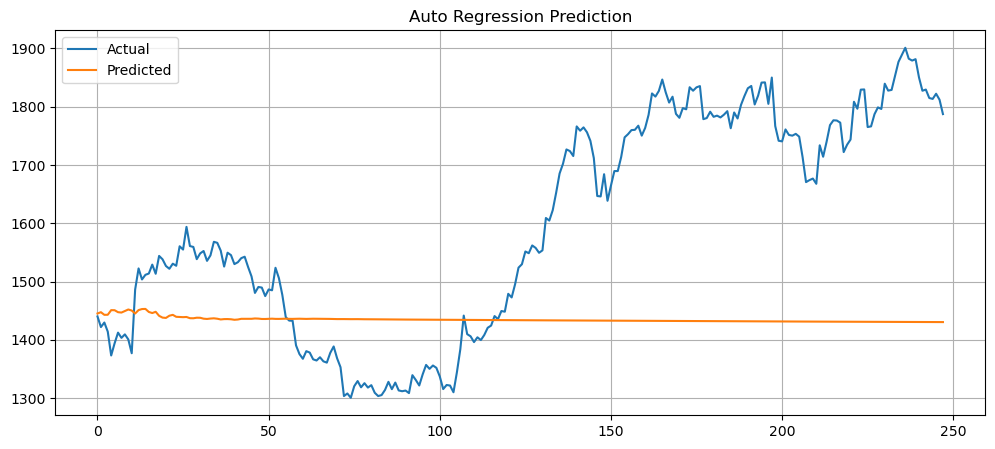

In [47]:
plt.figure(figsize=(12,5))
plt.plot(actual,label="Actual")
plt.plot(prediction,label="Predicted")
plt.legend()
plt.title("Auto Regression Prediction")
plt.grid()
plt.show()

In [48]:
future = model_fit.predict(start=len(scaled),end=len(scaled)+30)
future = scaler.inverse_transform(future.reshape(-1,1))

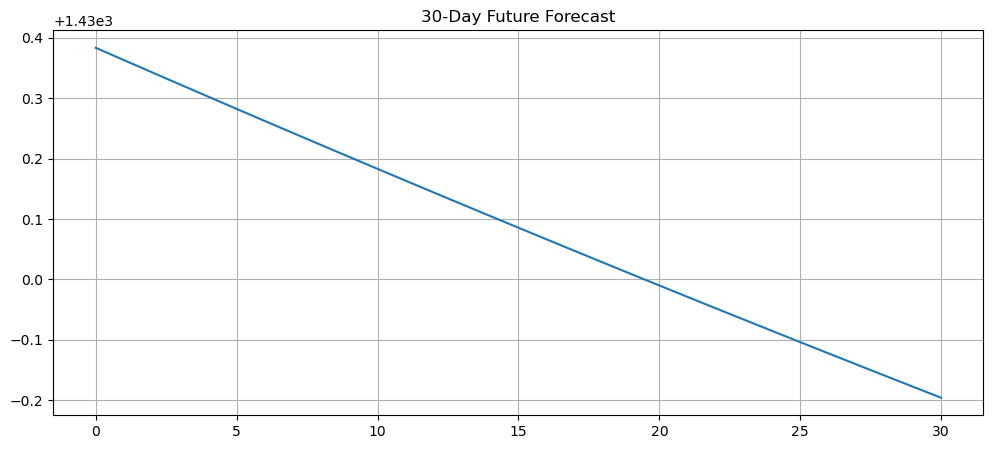

In [49]:
plt.figure(figsize=(12,5))
plt.plot(future)
plt.title("30-Day Future Forecast")
plt.grid()
plt.show()

In [50]:
forecast = pd.DataFrame(future,columns=["Forecast"])
forecast.head()

,Forecast
0,1430.383543
1,1430.363148
2,1430.342832
3,1430.322591
4,1430.302424
